# Classification

Reproduces the **cell-type classification** panels of the DeepCell Types paper: the confusion matrices (51-class and lineage-collapsed), the per-modality / per-tissue / per-lineage macro-F1 slices, the per-class precision-recall scatter, the cross-method macro-F1 benchmark (DeepCell Types vs XGBoost / XGBoost-tuned / MAPS / CellSighter), the per-dataset accuracy of the worst-served test FOVs, a per-channel inference-time benchmark (GPU-gated), and the XGBoost Optuna tuning-convergence diagnostic.

All figures use a consistent publication figure style (via `dct_figures.style`) and are reproduced from the **held-out test split**. DeepCell Types results exclude the cells the model abstains on (a flag precomputed in the released predictions); baselines use raw argmax.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))   # ensure dct_figures importable
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from dct_figures import paths, style, colors, scoring
style.apply_style()

## Shared config

Cell-type ordering and the lineage taxonomy come from `dct_figures`: the 51-class canonical order in `scoring.CT2IDX` and the lineage taxonomy shipped under `data/lineage_mapping.yaml`.

In [2]:
import yaml

ct2idx = scoring.CT2IDX
idx2ct = {v: k for k, v in ct2idx.items()}
n_classes = len(ct2idx)

with open(paths.DATA_ROOT / 'lineage_mapping.yaml') as f:
    lineage_mapping = yaml.safe_load(f)

DCT_CSV = paths.OUTPUT / 'deepcelltypes_test_prediction.csv'
print('classes:', n_classes, '| lineages:', sorted(set(lineage_mapping.values())))

classes: 51 | lineages: ['Endothelial', 'Epithelial', 'Lymphocyte', 'Myeloid', 'Nerve', 'Other', 'Stromal', 'Tumor']


### Prediction loader

Loads the From Scratch test-prediction CSV, derives the per-cell argmax prediction and max-softmax confidence, and the hierarchical-correctness flag (`scoring.CELL_TYPE_HIERARCHY`: a child prediction counts as correct for its parent and vice-versa).

In [3]:
from dct_figures.scoring import CELL_TYPE_HIERARCHY, adjust_conf_mat_hierarchy

def load_predictions_df(csv_path, ct2idx):
    df = pd.read_csv(csv_path)
    ct_columns = [c for c in df.columns if c in ct2idx]
    probs = df[ct_columns].values
    df['pred_name'] = np.array(ct_columns)[probs.argmax(axis=1)]
    df['max_prob'] = probs.max(axis=1)
    df['correct'] = df['cell_type_actual'] == df['pred_name']
    child_to_parent = {}
    for parent, children in CELL_TYPE_HIERARCHY.items():
        for child in children:
            child_to_parent[child] = parent
    # Unidirectional hierarchy collapse, matching
    # scoring.adjust_conf_mat_hierarchy: a child prediction counts as correct
    # only when the GT label is its parent (e.g. GT Tcell -> pred CD8T), not
    # the reverse. Keeps the per-dataset figure consistent with the headline F1.
    df['correct_hier'] = df.apply(
        lambda row: (
            row['correct']
            or child_to_parent.get(row['pred_name']) == row['cell_type_actual']
        ),
        axis=1,
    )
    return df, ct_columns

pred_df, ct_columns = load_predictions_df(paths.need(DCT_CSV), ct2idx)
print(f"Loaded {len(pred_df):,} predictions; "
      f"{pred_df['correct_hier'].sum():,} correct "
      f"({pred_df['correct_hier'].mean()*100:.1f}%)")

Loaded 486,705 predictions; 436,907 correct (89.8%)


## Confusion matrix (held-out test split) — Fig. 3a

Cell-type confusion matrix on the held-out test split (hierarchical-collapsed). Rows are hierarchically clustered (Ward linkage) and row-normalized; the diagonal annotation is the per-class recall.

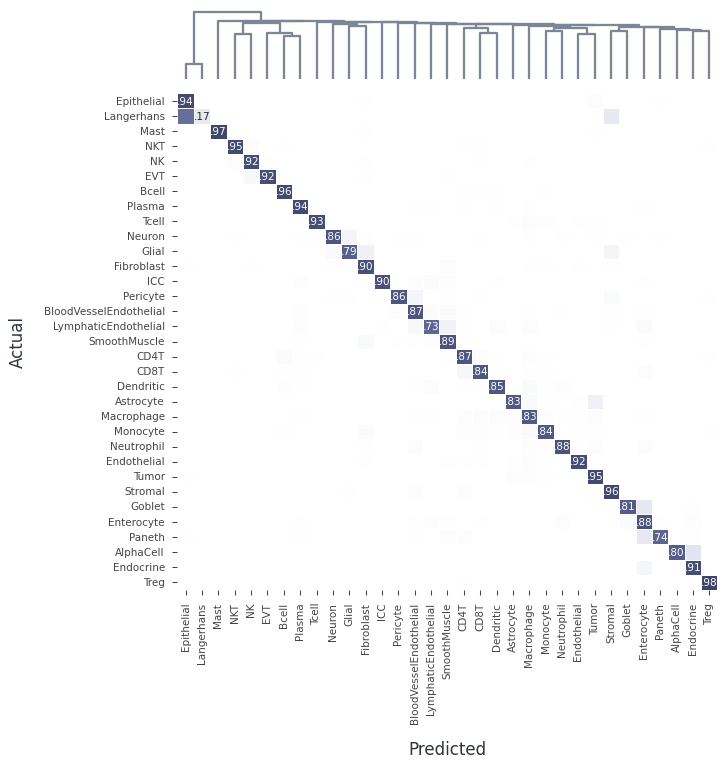

In [4]:
from scipy.cluster import hierarchy
from dct_figures.style import CMAP_BLUES, COL_1_5, PAL, FS_AXIS_LABEL, FS_TINY

# Raw 51x51 confusion matrix from argmax predictions.
conf_mat_raw = np.zeros((n_classes, n_classes), dtype=np.int64)
for t, p in zip(pred_df['cell_type_actual'], pred_df['pred_name']):
    if t in ct2idx and p in ct2idx:
        conf_mat_raw[ct2idx[t], ct2idx[p]] += 1
conf_mat_h = adjust_conf_mat_hierarchy(conf_mat_raw, CELL_TYPE_HIERARCHY, ct2idx)

support = conf_mat_h.sum(axis=1)
has_support = support > 0
kept_idx = [i for i in range(n_classes) if has_support[i]]
class_names = [idx2ct[i] for i in kept_idx]
cm = conf_mat_h[np.ix_(kept_idx, kept_idx)]
row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm / row_sums
cm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)

dist = 1 - cm_df.values
Z = hierarchy.linkage(dist, method='ward', optimal_ordering=True)
R = hierarchy.dendrogram(Z, labels=class_names, no_plot=True)
order = R['ivl']
cm_df = cm_df.loc[order, order]

fig = plt.figure(figsize=(COL_1_5, COL_1_5 * 1.05))
ax_dend = fig.add_axes([0.14, 0.80, 0.80, 0.10])
hierarchy.dendrogram(Z, ax=ax_dend, labels=class_names, no_labels=True,
                     count_sort=True, color_threshold=0,
                     above_threshold_color=PAL['gray'])
for s in ('top', 'right', 'bottom', 'left'):
    ax_dend.spines[s].set_visible(False)
ax_dend.set_yticks([])

ax_heat = fig.add_axes([0.14, 0.08, 0.80, 0.70])
diag_vals = np.diag(cm_df.values)
annot_str = np.full(cm_df.shape, '', dtype=object)
for i, v in enumerate(diag_vals):
    if v < 0.005:
        continue
    s = f'{v:.2f}'
    if s.startswith('0.'):
        s = s[1:]
    elif s == '1.00':
        s = '1.'
    annot_str[i, i] = s
sns.heatmap(cm_df, annot=annot_str, fmt='', cmap=CMAP_BLUES, ax=ax_heat,
            cbar=False, vmin=0, vmax=1, linewidths=0.3, linecolor='white',
            annot_kws={'fontsize': FS_TINY, 'fontweight': 'normal'})
ax_heat.set_xlabel('Predicted', labelpad=8, fontsize=FS_AXIS_LABEL)
ax_heat.set_ylabel('Actual', labelpad=8, fontsize=FS_AXIS_LABEL)
plt.setp(ax_heat.get_xticklabels(), ha='center', rotation=90, fontsize=FS_TINY)
plt.setp(ax_heat.get_yticklabels(), fontsize=FS_TINY)
plt.show()

## Lineage-collapsed confusion matrix — Supp. Fig. 5a

Lineage-collapsed confusion matrix (held-out test split, From Scratch, row-normalized) — 8x8 coarse-grained companion to the 51x51 panel.

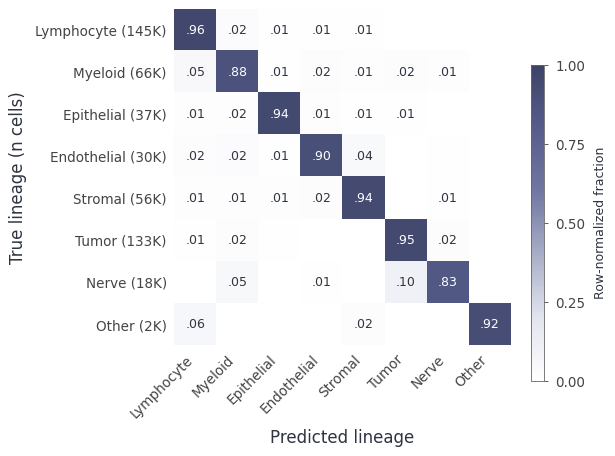

In [5]:
from dct_figures.style import LINEAGE_ORDER, CMAP_BLUES, COL_1, PAL
from dct_figures.style import FS_AXIS_LABEL, FS_TICK, FS_SMALL, _si_fmt

def _collapse_to_lineage(cm_ct, ct2idx, lineage_mapping, lineage_order):
    lineage_to_idx = {lin: i for i, lin in enumerate(lineage_order)}
    k = len(lineage_order)
    cm_lin = np.zeros((k, k), dtype=np.int64)
    idx2ct_l = {v: u for u, v in ct2idx.items()}
    for i in range(cm_ct.shape[0]):
        lin_i = lineage_mapping.get(idx2ct_l[i], 'Other')
        if lin_i not in lineage_to_idx:
            lin_i = 'Other'
        ii = lineage_to_idx[lin_i]
        for j in range(cm_ct.shape[1]):
            lin_j = lineage_mapping.get(idx2ct_l[j], 'Other')
            if lin_j not in lineage_to_idx:
                lin_j = 'Other'
            jj = lineage_to_idx[lin_j]
            cm_lin[ii, jj] += cm_ct[i, j]
    return cm_lin

cm_lin = _collapse_to_lineage(conf_mat_h, ct2idx, lineage_mapping, LINEAGE_ORDER)
support_l = cm_lin.sum(axis=1)
kept = [i for i, s in enumerate(support_l) if s > 0]
lineages_kept = [LINEAGE_ORDER[i] for i in kept]
cm_lin = cm_lin[np.ix_(kept, kept)]
support_l = support_l[kept]
rs = cm_lin.sum(axis=1, keepdims=True)
safe = np.where(rs == 0, 1, rs)
cm_lin_norm = cm_lin / safe
n = len(lineages_kept)

fig, ax = plt.subplots(figsize=(COL_1, COL_1))
im = ax.imshow(cm_lin_norm, cmap=CMAP_BLUES, vmin=0.0, vmax=1.0,
               aspect='equal', interpolation='nearest')

def _fmt(v):
    s = f'{v:.2f}'
    return s[1:] if s.startswith('0.') else s

for i in range(n):
    for j in range(n):
        v = cm_lin_norm[i, j]
        if v < 0.005:
            continue
        col = PAL['dark'] if v < 0.55 else 'white'
        ax.text(j, i, _fmt(v), ha='center', va='center',
                fontsize=FS_SMALL, color=col, zorder=3)
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(lineages_kept, rotation=45, ha='right', fontsize=FS_TICK)

def _round_for_label(nn):
    if nn >= 1_000_000:
        return int(round(nn / 100_000.0) * 100_000)
    if nn >= 1_000:
        return int(round(nn / 1_000.0) * 1_000)
    return int(nn)

y_labels = [f'{lin} ({_si_fmt(_round_for_label(int(s)))})'
            for lin, s in zip(lineages_kept, support_l)]
ax.set_yticklabels(y_labels, fontsize=FS_TICK)
ax.set_xlabel('Predicted lineage', fontsize=FS_AXIS_LABEL, labelpad=4)
ax.set_ylabel('True lineage (n cells)', fontsize=FS_AXIS_LABEL, labelpad=4)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='both', length=0)
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)
cax = fig.add_axes([0.92, 0.18, 0.025, 0.62])
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label('Row-normalized fraction', fontsize=FS_SMALL, labelpad=4)
cb.ax.tick_params(labelsize=FS_TICK, length=2, width=0.4)
cb.outline.set_linewidth(0.4)
cb.outline.set_edgecolor('#666666')
cb.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
fig.subplots_adjust(left=0.22, right=0.88, top=0.94, bottom=0.22)
plt.show()

## Macro-F1 by slice (modality / tissue / lineage)

The three slice panels exclude the cells the model abstains on (precomputed in
the released predictions), then report per-slice hierarchical macro F1 over the
has-support classes.

In [6]:
from dct_figures.style import (PAL, THEME, COL_1_5, FS_TICK, FS_SMALL,
    PERF_BAR_INCHES, PERF_BAR_PITCH_INCHES, setup_perf_bar_axes)

def _macro_f1_from_cm(cm):
    # Single source of truth for the metric: dct_figures.scoring.prf_from_cm.
    _, _, f1, support, has = scoring.prf_from_cm(cm)
    if not has.any():
        return float('nan'), 0, 0
    return float(f1[has].mean() * 100.0), int(has.sum()), int(support[has].sum())

def _slice_macro_f1(true_idx, pred_idx, mask, n_classes, ct2idx):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    m = mask & (true_idx >= 0) & (pred_idx >= 0)
    np.add.at(cm, (true_idx[m], pred_idx[m]), 1)
    cm = adjust_conf_mat_hierarchy(cm, CELL_TYPE_HIERARCHY, ct2idx)
    f1, ncls, _ = _macro_f1_from_cm(cm)
    return f1, ncls

def _aggregate(df, col, true_idx, pred_idx, kept_mask, n_classes, ct2idx):
    rows = []
    for key, grp in df.groupby(col, sort=False):
        in_slice = np.zeros(len(df), dtype=bool)
        in_slice[grp.index.to_numpy()] = True
        mask = in_slice & kept_mask
        n_kept = int(mask.sum())
        if n_kept == 0:
            continue
        f1, ncls = _slice_macro_f1(true_idx, pred_idx, mask, n_classes, ct2idx)
        rows.append({'slice': str(key), 'n_total': int(in_slice.sum()),
                     'n_kept': n_kept, 'n_classes': ncls, 'macro_f1': f1})
    return pd.DataFrame(rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)

def _bar_panel(table, colors=None):
    labels = table['slice'].tolist()
    f1 = table['macro_f1'].to_numpy()
    fig, ax = plt.subplots(figsize=(COL_1_5, 3.0))
    x, bar_w = setup_perf_bar_axes(fig, ax, len(labels),
                                   target_bar_inches=PERF_BAR_INCHES,
                                   target_pitch_inches=PERF_BAR_PITCH_INCHES)
    bars = ax.bar(x, f1, color=colors or THEME, edgecolor='white',
                  linewidth=0.8, zorder=3, width=bar_w)
    for bar, v in zip(bars, f1):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f'{v:.1f}',
                ha='center', va='bottom', fontsize=FS_SMALL, color=PAL['dark'])
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FS_TICK, rotation=30, ha='right')
    ax.set_ylabel('Macro F1 (%)')
    ax.set_ylim(0, max(np.nanmax(f1) * 1.15, 1.0))
    style.style_ax(ax)
    return fig

# Shared per-cell vectors + abstention mask for the slice panels.
_sl_df = pd.read_csv(DCT_CSV)
_ct_cols = [c for c in _sl_df.columns if c in ct2idx]
_probs = _sl_df[_ct_cols].to_numpy(dtype=np.float32)
_pred_names = np.array(_ct_cols)[_probs.argmax(axis=1)]
_true_names = _sl_df['cell_type_actual'].values
true_idx = np.array([ct2idx.get(t, -1) for t in _true_names])
pred_idx = np.array([ct2idx.get(p, -1) for p in _pred_names])
# Cells the model abstains on are flagged in the released predictions; exclude them.
kept = ~_sl_df['abstained'].to_numpy(dtype=bool)
_sl_df['lineage'] = [lineage_mapping.get(t, 'Other') for t in _true_names]
f1_all, ncls_all = _slice_macro_f1(true_idx, pred_idx, kept, n_classes, ct2idx)
print(f'Overall macro F1: {f1_all:.2f} '
      f'({ncls_all} classes; {int(kept.sum()):,} / {len(_sl_df):,} cells)')

Overall macro F1: 83.84 (33 classes; 399,366 / 486,705 cells)


### Macro F1 by imaging modality — Supp. Fig. 5c

From Scratch macro F1 on the held-out test split, grouped by imaging modality (hierarchical eval).

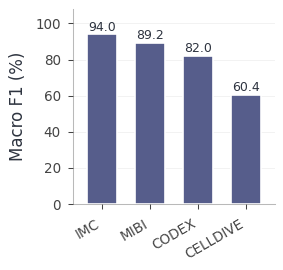

,slice,n_total,n_kept,n_classes,macro_f1
0,IMC,185988,151562,14,93.984889
1,MIBI,191304,155583,25,89.151242
2,CODEX,100625,84971,16,82.002021
3,CELLDIVE,8788,7250,16,60.365547


In [7]:
tbl_mod = _aggregate(_sl_df, 'modality', true_idx, pred_idx, kept, n_classes, ct2idx)
fig = _bar_panel(tbl_mod)
plt.show()
tbl_mod

### Macro F1 by tissue — Supp. Fig. 5e

From Scratch macro F1 on the held-out test split, grouped by tissue / organ (hierarchical eval).

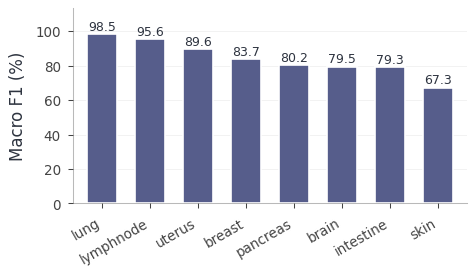

,slice,n_total,n_kept,n_classes,macro_f1
0,lung,100565,78835,13,98.537207
1,lymphnode,97063,78669,13,95.574450
2,uterus,16387,13101,12,89.566165
3,breast,22226,17714,15,83.714399
4,pancreas,18332,14670,15,80.155028
5,brain,86007,73261,14,79.474296
6,intestine,115880,98393,25,79.312685
7,skin,30245,24723,22,67.282885


In [8]:
tbl_tis = _aggregate(_sl_df, 'tissue', true_idx, pred_idx, kept, n_classes, ct2idx)
fig = _bar_panel(tbl_tis)
plt.show()
tbl_tis

### Macro F1 by lineage — Supp. Fig. 5d

From Scratch macro F1 on the held-out test split, grouped by true-label lineage (hierarchical eval); the 'Other' bucket is dropped.

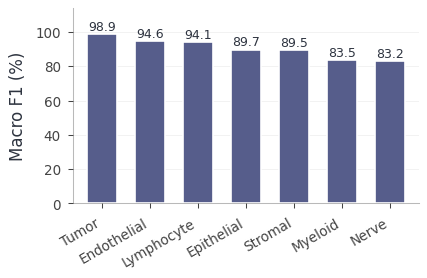

,slice,n_total,n_kept,n_classes,macro_f1
0,Tumor,132656,120402,1,98.902132
1,Endothelial,29693,23336,3,94.601164
2,Lymphocyte,145149,111163,8,94.142310
3,Epithelial,37391,33173,6,89.687085
4,Stromal,55937,47949,5,89.455704
5,Myeloid,66306,46632,6,83.480894
6,Nerve,17591,15144,3,83.197616


In [9]:
tbl_lin = _aggregate(_sl_df, 'lineage', true_idx, pred_idx, kept, n_classes, ct2idx)
tbl_lin = tbl_lin[tbl_lin['slice'] != 'Other'].reset_index(drop=True)
fig = _bar_panel(tbl_lin)
plt.show()
tbl_lin

## Per-class precision–recall — Supp. Fig. 5b

Per-class precision vs recall on the held-out test split (From Scratch, hierarchical eval); dot color encodes lineage, dot size encodes log(support); dashed gray curves are F1 isocontours.

33 classes with support; mean F1=0.742, mean P=0.697, mean R=0.858


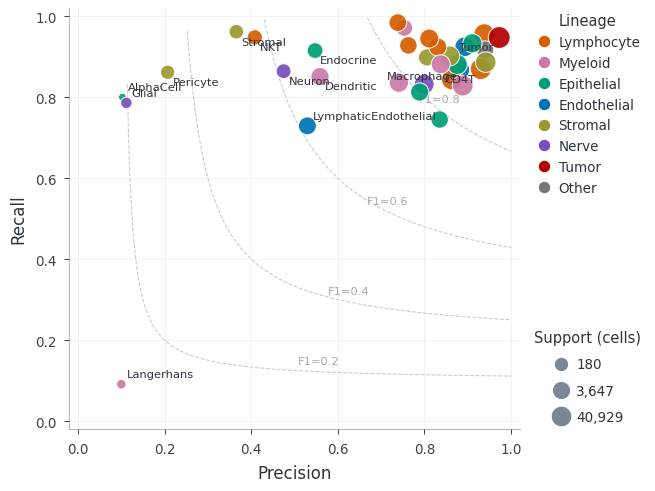

In [10]:
from matplotlib.lines import Line2D
from dct_figures.style import (PAL, LINEAGE_COLORS, COL_1, COL_1_5,
    FS_AXIS_LABEL, FS_BODY, FS_TICK, FS_SMALL)

def _f1_isocurve(F1, npts=200):
    x = np.linspace(F1 / 2 + 1e-4, 1.0, npts)
    y = (F1 * x) / (2 * x - F1)
    mask = (y >= 0.0) & (y <= 1.0)
    return x[mask], y[mask]

def _select_labels(df, f1_thresh=0.75, top_n_support=3):
    keep = set(df.index[df['f1'] < f1_thresh].tolist())
    keep.update(df['support'].nlargest(top_n_support).index.tolist())
    return sorted(keep)

# Hierarchical CM -> per-class precision/recall/F1 over has-support classes.
cm_pr = conf_mat_h
precision, recall, f1, support_pr, keep_pr = scoring.prf_from_cm(cm_pr)
support_pr = support_pr.astype(int)
kept_idx_pr = np.where(keep_pr)[0]
n_kept_pr = int(keep_pr.sum())
rows = []
for i in kept_idx_pr:
    ct = idx2ct[int(i)]
    rows.append({'cell_type': ct, 'precision': float(precision[i]),
                 'recall': float(recall[i]), 'f1': float(f1[i]),
                 'support': int(support_pr[i]),
                 'lineage': lineage_mapping.get(ct, 'Other')})
df_pr = pd.DataFrame(rows)
print(f"{n_kept_pr} classes with support; mean F1={df_pr['f1'].mean():.3f}, "
      f"mean P={df_pr['precision'].mean():.3f}, mean R={df_pr['recall'].mean():.3f}")

fig, ax = plt.subplots(figsize=(COL_1_5, COL_1))
for F1 in (0.2, 0.4, 0.6, 0.8):
    xs, ys = _f1_isocurve(F1)
    ax.plot(xs, ys, linestyle='--', linewidth=0.5, color=PAL['gray'],
            alpha=0.45, zorder=1)
    if len(xs) > 0:
        xi, yi = xs[-1], ys[-1]
        if yi < 0.97 and xi < 0.97:
            ax.text(min(xi + 0.01, 0.99), min(yi + 0.005, 0.99), f'F1={F1:.1f}',
                    fontsize=FS_SMALL - 0.5, color=PAL['gray'], alpha=0.7,
                    ha='left', va='bottom', zorder=1)
        else:
            mid = len(xs) // 2
            ax.text(xs[mid], ys[mid] + 0.015, f'F1={F1:.1f}',
                    fontsize=FS_SMALL - 0.5, color=PAL['gray'], alpha=0.7,
                    ha='center', va='bottom', zorder=1)
sup = df_pr['support'].values.astype(float)
log_sup = np.log10(np.clip(sup, 1, None))
s_min, s_max = 14.0, 110.0
if log_sup.max() > log_sup.min():
    sizes = s_min + (log_sup - log_sup.min()) / (log_sup.max() - log_sup.min()) * (s_max - s_min)
else:
    sizes = np.full_like(log_sup, (s_min + s_max) / 2)
scolors = [LINEAGE_COLORS.get(l, LINEAGE_COLORS.get('Other', PAL['gray']))
           for l in df_pr['lineage'].values]
ax.scatter(df_pr['precision'].values, df_pr['recall'].values, s=sizes,
           c=scolors, edgecolor='white', linewidth=0.5, alpha=0.92, zorder=3)
for i in _select_labels(df_pr):
    x0 = float(df_pr.loc[i, 'precision']); y0 = float(df_pr.loc[i, 'recall'])
    ct = str(df_pr.loc[i, 'cell_type'])
    dx = 0.012 if x0 < 0.85 else -0.012
    dy = 0.012 if y0 < 0.85 else -0.012
    ha = 'left' if dx >= 0 else 'right'
    va = 'bottom' if dy >= 0 else 'top'
    ax.annotate(ct, xy=(x0, y0), xytext=(x0 + dx, y0 + dy),
                fontsize=FS_SMALL - 0.5, color=PAL['dark'], ha=ha, va=va,
                zorder=4, annotation_clip=False)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_xticks(np.arange(0, 1.01, 0.2)); ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.set_xlabel('Precision', fontsize=FS_AXIS_LABEL)
ax.set_ylabel('Recall', fontsize=FS_AXIS_LABEL)
style.style_ax(ax, grid_axis='both')
lineages_present = [l for l in LINEAGE_COLORS.keys() if l in set(df_pr['lineage'].values)]
color_handles = [Line2D([0], [0], marker='o', linestyle='none', markersize=6,
                        markeredgecolor='white', markeredgewidth=0.5,
                        markerfacecolor=LINEAGE_COLORS[l], label=l)
                 for l in lineages_present]
leg1 = ax.legend(handles=color_handles, title='Lineage', loc='upper left',
                 bbox_to_anchor=(1.02, 1.0), fontsize=FS_TICK,
                 title_fontsize=FS_BODY, frameon=False, borderaxespad=0.0,
                 handletextpad=0.4)
ax.add_artist(leg1)
if log_sup.max() > log_sup.min():
    q_lo, q_md, q_hi = np.quantile(sup, [0.1, 0.5, 0.9])
    ref_supports = sorted({max(1, int(q_lo)), max(1, int(q_md)), max(1, int(q_hi))})
else:
    ref_supports = [int(sup.max())]
def _size_for(s_val):
    ls = np.log10(max(1, s_val))
    if log_sup.max() > log_sup.min():
        return s_min + (ls - log_sup.min()) / (log_sup.max() - log_sup.min()) * (s_max - s_min)
    return (s_min + s_max) / 2
size_handles = [Line2D([0], [0], marker='o', linestyle='none',
                       markersize=np.sqrt(_size_for(s_val)),
                       markeredgecolor='white', markeredgewidth=0.5,
                       markerfacecolor=PAL['gray'], label=f'{s_val:,}')
                for s_val in ref_supports]
ax.legend(handles=size_handles, title='Support (cells)', loc='lower left',
          bbox_to_anchor=(1.02, 0.0), fontsize=FS_TICK, title_fontsize=FS_BODY,
          frameon=False, borderaxespad=0.0, handletextpad=0.4, labelspacing=0.9)
fig.tight_layout()
plt.show()

## Cross-method benchmark (macro F1) — Fig. 3c

Macro F1 on the held-out test split across DeepCell Types + 4 baselines (single bar chart). DeepCell Types excludes the cells it abstains on (precomputed in the released predictions); baselines use raw argmax. Scored via `scoring.score_csv`.

  DCT: macro_F1 = 83.84 (n=33 classes, coverage=82.1%)


  CellSighter: macro_F1 = 70.36 (n=33 classes, coverage=100.0%)


  MAPS: macro_F1 = 67.26 (n=33 classes, coverage=100.0%)


  XGBoost: macro_F1 = 77.43 (n=33 classes, coverage=100.0%)


  XGBoost (tuned): macro_F1 = 79.03 (n=33 classes, coverage=100.0%)


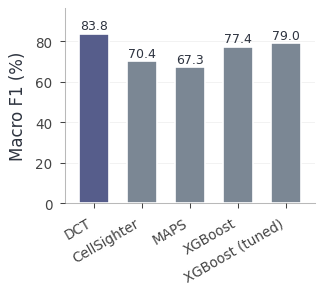

In [11]:
from dct_figures.style import (PAL, COL_1_5, FS_TICK, FS_SMALL,
    PERF_BAR_INCHES, PERF_BAR_PITCH_INCHES, method_bar_color, setup_perf_bar_axes)

METHODS = [
    ('DCT',             'deepcelltypes_test_prediction.csv'),
    ('CellSighter',     'baseline_cellsighter_test_prediction.csv'),
    ('MAPS',            'baseline_maps_test_prediction.csv'),
    ('XGBoost',         'final_xgb_plain_test_prediction.csv'),
    ('XGBoost (tuned)', 'baseline_xgb_tuned_test_prediction.csv'),
]
rows = []
for label, fname in METHODS:
    csv_path = paths.OUTPUT / fname
    if not csv_path.exists():
        print(f'  SKIP {label}: {csv_path} missing')
        continue
    s = scoring.score_csv(csv_path, ct2idx)
    rows.append((label, s))
    print(f"  {label}: macro_F1 = {s['macro_f1']:.2f} "
          f"(n={s['n_classes_with_support']} classes, "
          f"coverage={s['coverage']*100:.1f}%)")
labels = [r[0] for r in rows]
f1 = np.array([r[1]['macro_f1'] for r in rows])
bcolors = [method_bar_color(lbl) for lbl in labels]

fig, ax = plt.subplots(figsize=(COL_1_5, 3.0))
x, bar_w = setup_perf_bar_axes(fig, ax, len(labels),
                               target_bar_inches=PERF_BAR_INCHES,
                               target_pitch_inches=PERF_BAR_PITCH_INCHES)
bars = ax.bar(x, f1, color=bcolors, edgecolor='white', linewidth=0.8,
              zorder=3, width=bar_w)
for bar, v in zip(bars, f1):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f'{v:.1f}',
            ha='center', va='bottom', fontsize=FS_SMALL, color=PAL['dark'])
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=FS_TICK, rotation=30, ha='right')
ax.set_ylabel('Macro F1 (%)')
ax.set_ylim(0, max(f1) * 1.15)
style.style_ax(ax)
plt.show()

## Per-dataset cell-type accuracy — Supp. Fig. 6a

_Caption:_ Per-dataset (per-FOV) cell-type accuracy on the held-out test split, worst 40 of 129 FOVs, ordered ascending. Accuracy is the fraction of a FOV's cells whose prediction is hierarchically correct. The worst-served FOVs are typically those with small panels or unusual marker sets, consistent with the panel-agnostic generalization envelope.

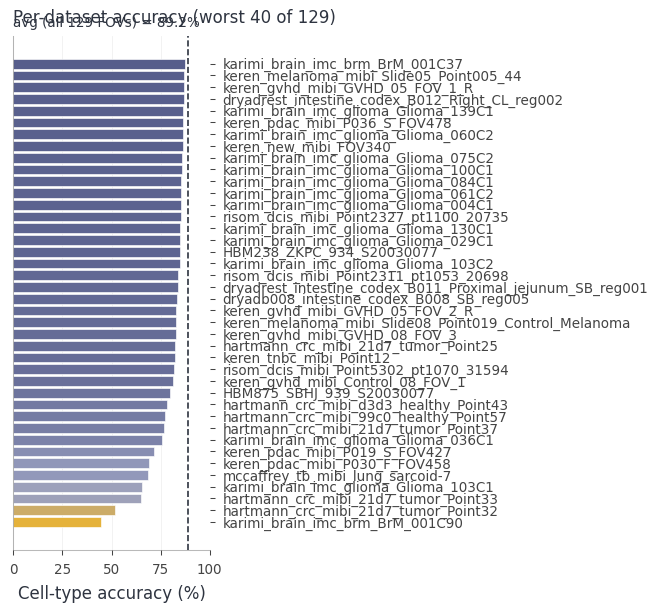

per-FOV accuracy: worst 44.6% .. median 90.6% .. best 99.1% (n=129)


In [12]:
# Per-FOV hierarchical cell-type accuracy on the held-out test split: the worst
# 40 of the test FOVs (horizontal, least-bad at top -> worst at bottom), each
# bar colored by its accuracy (gold = lowest). The worst-served FOVs tend to be
# small-panel / unusual-marker acquisitions.
from dct_figures.style import FS_AXIS_LABEL, FS_TICK, FS_TINY, style_ax
from matplotlib.colors import LinearSegmentedColormap

fov_acc = pred_df.groupby("fov_name")["correct_hier"].mean()
n_fov = len(fov_acc)
worst = fov_acc.sort_values(ascending=False).tail(40)   # 40 lowest; least-bad first
acc = worst.to_numpy() * 100.0

_cmap = LinearSegmentedColormap.from_list("acc", ["#E5B23B", "#9aa0c0", THEME])
_norm = (acc - acc.min()) / max(acc.max() - acc.min(), 1e-9)
bar_colors = _cmap(_norm)

fig, ax = plt.subplots(figsize=(COL_1_5, 4.2))
y = range(len(worst))
ax.barh(y, acc, color=bar_colors, edgecolor="white", linewidth=0.3, height=0.82)
ax.invert_yaxis()                       # least-bad at top, worst at bottom
ax.set_yticks(list(y)); ax.set_yticklabels(worst.index, fontsize=FS_TINY)
ax.yaxis.tick_right()
ax.set_xlim(0, 100)
ax.set_xlabel("Cell-type accuracy (%)", fontsize=FS_AXIS_LABEL)
mean_acc = fov_acc.mean() * 100.0
ax.axvline(mean_acc, color=PAL["dark"], linestyle="--", linewidth=0.8, zorder=4)
ax.text(0.0, 1.01, f"avg (all {n_fov} FOVs) = {mean_acc:.1f}%", transform=ax.transAxes,
        ha="left", va="bottom", fontsize=FS_TICK, color=PAL["dark"])
ax.set_title(f"Per-dataset accuracy (worst 40 of {n_fov})", fontsize=FS_AXIS_LABEL, loc="left")
ax.tick_params(labelsize=FS_TICK)
style_ax(ax, grid_axis="x")
fig.tight_layout()
plt.show()
print(f"per-FOV accuracy: worst {acc.min():.1f}% .. median {fov_acc.median()*100:.1f}% "
      f".. best {fov_acc.max()*100:.1f}% (n={n_fov})")

## Per-channel inference time — Supp. Fig. 6b

_Caption:_ Per-channel inference time scales linearly with the number of cells; on average ~0.24 ± 0.07 ms per cell per channel.

> This panel times `model.forward()` over a sweep of cell counts and panel sizes, so it needs a **GPU, the released checkpoint, and the `deepcell-types` package** — it cannot be reproduced from the released CSVs alone. The benchmark is provided below behind `RUN_INFERENCE_BENCHMARK` (off by default so this notebook stays runnable and torch-free; set it `True` on a GPU box with `DATA_DIR` pointing at the archive).

In [13]:
# Supp. Fig. 6b -- per-channel inference-time benchmark.
# OFF by default: needs a GPU + the deepcell-types package; timings are
# weight-independent (random/zero weights are fine), so no checkpoint is
# required. Set RUN_INFERENCE_BENCHMARK=True on a GPU box (DATA_DIR set).
RUN_INFERENCE_BENCHMARK = False

if not RUN_INFERENCE_BENCHMARK:
    print("skipped: Supp. Fig. 6b needs a GPU + the deepcell-types package; "
          "set RUN_INFERENCE_BENCHMARK=True to run.")
    print("published result: ~0.24 +/- 0.07 ms per cell per channel "
          "(inference time scales linearly with cell count).")
else:
    import time
    import torch
    import matplotlib.colors as mcolors
    from deepcell_types.training.config import TissueNetConfig
    from deepcell_types.model import create_model
    from dct_figures.style import FS_AXIS_LABEL, FS_TICK, style_ax

    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    config = TissueNetConfig(str(paths.EXPANDED_TISSUENET_ZARR))
    marker_embeddings = np.zeros((len(config.marker2idx), 328), dtype="float32")
    model = (create_model(config, marker_embeddings, d_model=256,
                          resnet_base_channels=48).to(device).eval())
    c_max = getattr(config, "MAX_NUM_CHANNELS", 75)
    cells = [500, 1000, 2500, 5000, 10000, 20000, 40000]
    channels = [24, 32, 40, 48, 56]
    bs = 128

    def _batch(n_ch):
        s = torch.zeros(bs, c_max, 1, 64, 64, device=device)
        sp = torch.zeros(bs, 3, 64, 64, device=device)
        ci = torch.zeros(bs, c_max, dtype=torch.long, device=device)
        pm = torch.ones(bs, c_max, dtype=torch.bool, device=device)
        pm[:, :n_ch] = False
        ci[:, :n_ch] = torch.arange(n_ch, device=device)[None].expand(bs, -1)
        return s, sp, ci, pm

    def _time(batch, n_warmup=2, n_iters=3):
        for _ in range(n_warmup):
            with torch.no_grad():
                model(*batch)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n_iters):
            with torch.no_grad():
                model(*batch)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        return (time.perf_counter() - t0) / n_iters

    rows = []
    for n_ch in channels:
        for n_cells in cells:
            n_batches = max(1, n_cells // bs)
            actual = n_batches * bs
            t_total = _time(_batch(n_ch)) * n_batches
            rows.append({"n_channels": n_ch, "n_cells": actual,
                         "t_per_ch_s": t_total / n_ch})
    bdf = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(3.4, 3.2))
    cmap = plt.get_cmap("viridis")
    norm = mcolors.Normalize(vmin=min(channels), vmax=max(channels))
    for n_ch, sub in bdf.groupby("n_channels"):
        ax.scatter(sub["n_cells"], sub["t_per_ch_s"], c=[cmap(norm(n_ch))] * len(sub),
                   s=24, alpha=0.85, edgecolor="white", linewidth=0.6, label=str(n_ch))
    ax.set_xlabel("Cells per FOV", fontsize=FS_AXIS_LABEL)
    ax.set_ylabel("Inference time / channel (s)", fontsize=FS_AXIS_LABEL)
    ax.legend(title="Panel size", fontsize=FS_TICK)
    ax.tick_params(labelsize=FS_TICK)
    style_ax(ax)
    plt.show()


skipped: Supp. Fig. 6b needs a GPU + the deepcell-types package; set RUN_INFERENCE_BENCHMARK=True to run.
published result: ~0.24 +/- 0.07 ms per cell per channel (inference time scales linearly with cell count).


## XGBoost tuning convergence — Supp. Fig. 6c

Optuna trial progression — XGBoost hyperparameter sweep convergence. Shows per-trial objective (scatter), best-so-far running max, and the stagnation region after the last improvement (demonstrating that 50 trials sufficed).

  best: 0.7365 at trial 38, plateau 11 trials


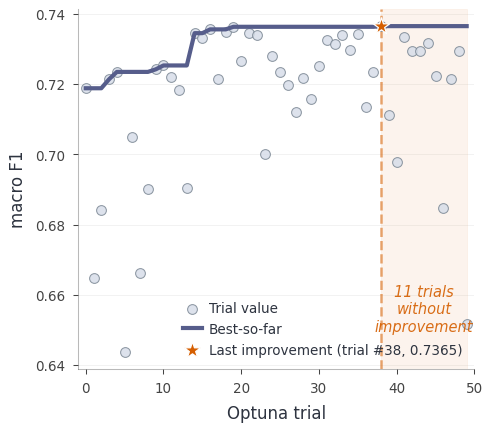

In [14]:
from dct_figures.style import PAL, COL_1, FS_BODY, FS_TICK

history = paths.OUTPUT / 'tuning' / 'xgb_tune_history.csv'
metric_label = 'macro F1'
df_h = pd.read_csv(paths.need(history)).sort_values('number').reset_index(drop=True)
df_h['best_so_far'] = df_h['value'].cummax()
n = len(df_h)
best_val = df_h['value'].max()
best_idx = int(df_h.loc[df_h['value'].idxmax(), 'number'])
stagnation = n - 1 - best_idx

fig, ax = plt.subplots(figsize=(COL_1, 3.0))
ax.scatter(df_h['number'], df_h['value'], s=22, color=PAL['light_gray'],
           edgecolor=PAL['gray'], linewidth=0.5, alpha=0.85, zorder=3,
           label='Trial value')
ax.plot(df_h['number'], df_h['best_so_far'], color=PAL['blue'], linewidth=2.0,
        zorder=4, label='Best-so-far')
if stagnation > 0:
    ax.axvspan(best_idx, n - 1, color=PAL['red'], alpha=0.07, zorder=1)
    ax.text((best_idx + (n - 1)) / 2, df_h['value'].min() + 0.005,
            f'{stagnation} trials\nwithout\nimprovement', ha='center',
            va='bottom', fontsize=FS_BODY, color=PAL['red'], alpha=0.9,
            style='italic')
ax.axvline(best_idx, color=PAL['red'], linewidth=1.2, alpha=0.55,
           linestyle='--', zorder=2)
ax.scatter([best_idx], [best_val], s=70, marker='*', color=PAL['red'],
           edgecolor='white', linewidth=0.6, zorder=5,
           label=f'Last improvement (trial #{best_idx}, {best_val:.4f})')
ax.set_xlabel('Optuna trial')
ax.set_ylabel(metric_label)
ax.set_xlim(-1, n)
ax.set_ylim(df_h['value'].min() - 0.005, best_val + 0.005)
ax.legend(loc='lower right', fontsize=FS_TICK, framealpha=0.95)
style.style_ax(ax, grid_axis='y')
fig.tight_layout()
print(f'  best: {best_val:.4f} at trial {best_idx}, plateau {stagnation} trials')
plt.show()